# Tokenizers from Scratch

## The Foundation Every LLM Stands On

---

## Why Tokenization Matters More Than You Think

Every language model - GPT-2, GPT-4, LLaMA, Claude - starts with the same question:

**How do we convert text into numbers?**

This seemingly simple question has profound implications:

- **Vocabulary size** affects model size (embedding matrix = vocab × dim)
- **Token boundaries** affect what the model can learn
- **Unknown tokens** mean information loss
- **Tokenization efficiency** affects context length

This notebook covers:

1. **The Evolution** - From characters to subwords
2. **Byte Pair Encoding (BPE)** - Complete implementation
3. **Byte-Level BPE** - The GPT-2 innovation
4. **WordPiece** - The BERT approach
5. **Unigram** - The probabilistic alternative
6. **Comparison** - Which tokenizer for which model?
7. **Building a Production Tokenizer** - With all the features

In [1]:
import re
import json
import unicodedata
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from tqdm.auto import tqdm
import heapq

plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

np.random.seed(42)

print("Ready to build tokenizers from scratch!")

Ready to build tokenizers from scratch!


---

## 1. The Evolution of Tokenization

### 1.1 Why Not Just Use Characters?

The simplest approach: one token per character.

In [2]:
class CharacterTokenizer:
    """
    Simplest possible tokenizer: one token per character.
    """

    def __init__(self):
        self.char_to_id = {}
        self.id_to_char = {}

    def train(self, text: str):
        """Build vocabulary from text."""
        chars = sorted(set(text))
        self.char_to_id = {c: i for i, c in enumerate(chars)}
        self.id_to_char = {i: c for c, i in self.char_to_id.items()}

    def encode(self, text: str) -> List[int]:
        return [self.char_to_id.get(c, 0) for c in text]

    def decode(self, ids: List[int]) -> str:
        return ''.join(self.id_to_char.get(i, '?') for i in ids)

    @property
    def vocab_size(self) -> int:
        return len(self.char_to_id)


# Test character tokenizer
text = "Hello, world! How are you today?"
char_tok = CharacterTokenizer()
char_tok.train(text)

encoded = char_tok.encode(text)
decoded = char_tok.decode(encoded)

print("CHARACTER TOKENIZER")
print("=" * 60)
print(f"Text: '{text}'")
print(f"Tokens: {encoded}")
print(f"Length: {len(encoded)} tokens")
print(f"Vocab size: {char_tok.vocab_size}")
print(f"Decoded: '{decoded}'")

CHARACTER TOKENIZER
Text: 'Hello, world! How are you today?'
Tokens: [4, 7, 8, 8, 9, 2, 0, 13, 9, 10, 8, 6, 1, 0, 4, 9, 13, 0, 5, 10, 7, 0, 14, 9, 12, 0, 11, 9, 6, 5, 14, 3]
Length: 32 tokens
Vocab size: 15
Decoded: 'Hello, world! How are you today?'


**Problems with character tokenization:**

1. **Long sequences**: "Hello" = 5 tokens, but it's one semantic unit
2. **No shared meaning**: 'c' in "cat" and 'c' in "car" are the same token but mean nothing
3. **Harder to learn**: Model must learn to compose characters into words

### 1.2 Why Not Just Use Words?

In [3]:
class WordTokenizer:
    """
    Simple word-level tokenizer.
    """

    def __init__(self, max_vocab: int = 10000):
        self.max_vocab = max_vocab
        self.word_to_id = {}
        self.id_to_word = {}
        self.unk_token = "<UNK>"
        self.unk_id = 0

    def _tokenize(self, text: str) -> List[str]:
        """Split text into words."""
        # Simple whitespace + punctuation splitting
        return re.findall(r"\w+|[^\w\s]", text.lower())

    def train(self, text: str):
        """Build vocabulary from text."""
        words = self._tokenize(text)
        word_counts = Counter(words)

        # Keep most common words
        most_common = word_counts.most_common(self.max_vocab - 1)

        self.word_to_id = {self.unk_token: 0}
        for i, (word, _) in enumerate(most_common, 1):
            self.word_to_id[word] = i

        self.id_to_word = {i: w for w, i in self.word_to_id.items()}

    def encode(self, text: str) -> List[int]:
        words = self._tokenize(text)
        return [self.word_to_id.get(w, self.unk_id) for w in words]

    def decode(self, ids: List[int]) -> str:
        return ' '.join(self.id_to_word.get(i, self.unk_token) for i in ids)

    @property
    def vocab_size(self) -> int:
        return len(self.word_to_id)


# Test word tokenizer
training_text = "The cat sat on the mat. The dog sat on the log. The cat and the dog played."
test_text = "The bird sat on the tree."  # 'bird' and 'tree' are OOV

word_tok = WordTokenizer()
word_tok.train(training_text)

print("WORD TOKENIZER")
print("=" * 60)
print(f"Training text: '{training_text}'")
print(f"Vocab: {list(word_tok.word_to_id.keys())}")
print(f"\nTest text: '{test_text}'")

encoded = word_tok.encode(test_text)
decoded = word_tok.decode(encoded)

print(f"Tokens: {encoded}")
print(f"Decoded: '{decoded}'")
print(f"\nPROBLEM: 'bird' and 'tree' became <UNK>!")

WORD TOKENIZER
Training text: 'The cat sat on the mat. The dog sat on the log. The cat and the dog played.'
Vocab: ['<UNK>', 'the', '.', 'cat', 'sat', 'on', 'dog', 'mat', 'log', 'and', 'played']

Test text: 'The bird sat on the tree.'
Tokens: [1, 0, 4, 5, 1, 0, 2]
Decoded: 'the <UNK> sat on the <UNK> .'

PROBLEM: 'bird' and 'tree' became <UNK>!


**Problems with word tokenization:**

1. **Unknown words (OOV)**: New words become `<UNK>`, losing information
2. **Huge vocabulary**: English has 170,000+ words, medical/legal add more
3. **No morphology**: "run", "running", "runs" are completely separate
4. **Rare words**: Most words appear rarely, hard to learn good embeddings

### 1.3 The Solution: Subword Tokenization

The key insight: **Break words into meaningful pieces.**

- "running" → "run" + "ning"
- "unhappiness" → "un" + "happi" + "ness"
- "transformers" → "transform" + "ers"

Benefits:
- Small vocabulary (~50K) covers virtually any text
- Morphological relationships are preserved
- No unknown tokens (can fall back to characters)

/tmp/ipython-input-4213622941.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


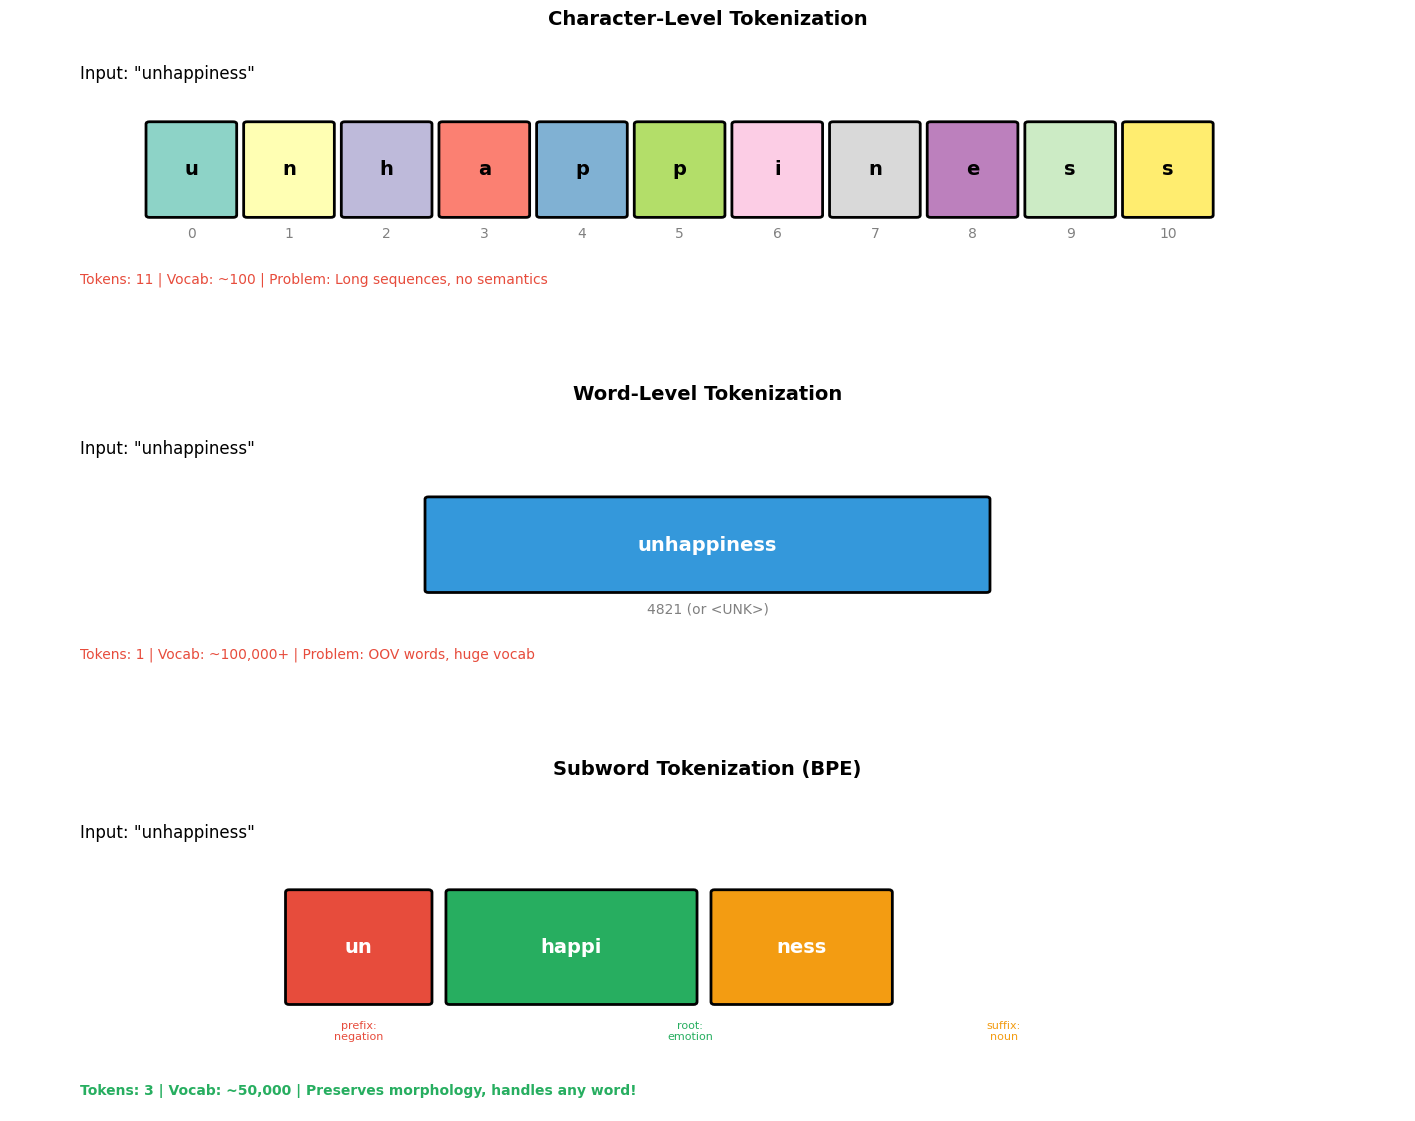

In [4]:
def visualize_tokenization_evolution():
    """
    Visualize the evolution of tokenization approaches.
    """
    fig = plt.figure(figsize=(18, 14))

    gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1.2], hspace=0.35)

    example = "unhappiness"

    # === CHARACTER LEVEL ===
    ax1 = fig.add_subplot(gs[0])
    ax1.set_xlim(0, 20)
    ax1.set_ylim(0, 6)
    ax1.axis('off')
    ax1.set_title('Character-Level Tokenization', fontsize=14, fontweight='bold')

    chars = list(example)
    colors = plt.cm.Set3(np.linspace(0, 1, len(chars)))

    for i, (char, color) in enumerate(zip(chars, colors)):
        x = 2 + i * 1.4
        rect = FancyBboxPatch((x, 2), 1.2, 2, boxstyle="round,pad=0.05",
                              facecolor=color, edgecolor='black', linewidth=2)
        ax1.add_patch(rect)
        ax1.text(x + 0.6, 3, char, ha='center', va='center',
                fontsize=14, fontweight='bold')
        ax1.text(x + 0.6, 1.5, str(i), ha='center', fontsize=10, color='gray')

    ax1.text(1, 5, f'Input: "{example}"', fontsize=12)
    ax1.text(1, 0.5, f'Tokens: {len(chars)} | Vocab: ~100 | Problem: Long sequences, no semantics',
             fontsize=10, color='#e74c3c')

    # === WORD LEVEL ===
    ax2 = fig.add_subplot(gs[1])
    ax2.set_xlim(0, 20)
    ax2.set_ylim(0, 6)
    ax2.axis('off')
    ax2.set_title('Word-Level Tokenization', fontsize=14, fontweight='bold')

    rect = FancyBboxPatch((6, 2), 8, 2, boxstyle="round,pad=0.05",
                          facecolor='#3498db', edgecolor='black', linewidth=2)
    ax2.add_patch(rect)
    ax2.text(10, 3, example, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')
    ax2.text(10, 1.5, '4821 (or <UNK>)', ha='center', fontsize=10, color='gray')

    ax2.text(1, 5, f'Input: "{example}"', fontsize=12)
    ax2.text(1, 0.5, f'Tokens: 1 | Vocab: ~100,000+ | Problem: OOV words, huge vocab',
             fontsize=10, color='#e74c3c')

    # === SUBWORD LEVEL ===
    ax3 = fig.add_subplot(gs[2])
    ax3.set_xlim(0, 20)
    ax3.set_ylim(0, 6)
    ax3.axis('off')
    ax3.set_title('Subword Tokenization (BPE)', fontsize=14, fontweight='bold')

    subwords = ['un', 'happi', 'ness']
    subword_colors = ['#e74c3c', '#27ae60', '#f39c12']
    widths = [2, 3.5, 2.5]

    x = 4
    for subword, color, width in zip(subwords, subword_colors, widths):
        rect = FancyBboxPatch((x, 2), width, 2, boxstyle="round,pad=0.05",
                              facecolor=color, edgecolor='black', linewidth=2)
        ax3.add_patch(rect)
        ax3.text(x + width/2, 3, subword, ha='center', va='center',
                fontsize=14, fontweight='bold', color='white')
        x += width + 0.3

    # Morphological meaning
    ax3.text(5, 1.3, 'prefix:\nnegation', ha='center', fontsize=8, color='#e74c3c')
    ax3.text(9.75, 1.3, 'root:\nemotion', ha='center', fontsize=8, color='#27ae60')
    ax3.text(14.25, 1.3, 'suffix:\nnoun', ha='center', fontsize=8, color='#f39c12')

    ax3.text(1, 5, f'Input: "{example}"', fontsize=12)
    ax3.text(1, 0.3, f'Tokens: 3 | Vocab: ~50,000 | Preserves morphology, handles any word!',
             fontsize=10, color='#27ae60', fontweight='bold')

    plt.tight_layout()
    plt.show()

visualize_tokenization_evolution()

---

## 2. Byte Pair Encoding (BPE) - Complete Implementation

### 2.1 The Algorithm

BPE was originally a compression algorithm. The idea is simple:

1. Start with characters as the vocabulary
2. Count all adjacent pairs
3. Merge the most frequent pair into a new token
4. Repeat until desired vocab size

### 2.2 Step-by-Step Example

In [5]:
def demonstrate_bpe_steps(corpus: str, num_merges: int = 10):
    """
    Demonstrate BPE step by step.
    """
    print("BPE ALGORITHM DEMONSTRATION")
    print("=" * 70)
    print(f"Corpus: '{corpus}'")
    print("=" * 70)

    # Preprocessing: split into words, add end-of-word marker
    # This prevents merges across word boundaries
    words = corpus.lower().split()

    # Represent words as tuples of characters with </w> marker
    word_freqs = Counter(words)
    splits = {word: list(word) + ['</w>'] for word in word_freqs}

    print(f"\nInitial splits (with end-of-word marker):")
    for word, freq in word_freqs.items():
        print(f"  '{word}' ({freq}x): {splits[word]}")

    vocab = set()
    for word in splits:
        vocab.update(splits[word])
    print(f"\nInitial vocab ({len(vocab)}): {sorted(vocab)}")

    merges = []

    for i in range(num_merges):
        # Count pairs
        pair_counts = Counter()
        for word, freq in word_freqs.items():
            symbols = splits[word]
            for j in range(len(symbols) - 1):
                pair_counts[(symbols[j], symbols[j+1])] += freq

        if not pair_counts:
            break

        # Find most common pair
        best_pair = pair_counts.most_common(1)[0]
        pair, count = best_pair

        print(f"\n--- Merge {i+1} ---")
        print(f"Most common pair: {pair} (count: {count})")

        # Merge the pair
        new_token = pair[0] + pair[1]
        merges.append((pair, new_token))
        vocab.add(new_token)

        # Update splits
        for word in splits:
            symbols = splits[word]
            new_symbols = []
            j = 0
            while j < len(symbols):
                if j < len(symbols) - 1 and (symbols[j], symbols[j+1]) == pair:
                    new_symbols.append(new_token)
                    j += 2
                else:
                    new_symbols.append(symbols[j])
                    j += 1
            splits[word] = new_symbols

        print(f"New token: '{new_token}'")
        print(f"Updated splits:")
        for word, freq in word_freqs.items():
            print(f"  '{word}': {splits[word]}")

    print(f"\n" + "=" * 70)
    print(f"Final vocab size: {len(vocab)}")
    print(f"Merges performed: {merges}")

    return vocab, merges, splits


# Demonstrate
corpus = "low lower lowest low lower"
vocab, merges, splits = demonstrate_bpe_steps(corpus, num_merges=8)

BPE ALGORITHM DEMONSTRATION
Corpus: 'low lower lowest low lower'

Initial splits (with end-of-word marker):
  'low' (2x): ['l', 'o', 'w', '</w>']
  'lower' (2x): ['l', 'o', 'w', 'e', 'r', '</w>']
  'lowest' (1x): ['l', 'o', 'w', 'e', 's', 't', '</w>']

Initial vocab (8): ['</w>', 'e', 'l', 'o', 'r', 's', 't', 'w']

--- Merge 1 ---
Most common pair: ('l', 'o') (count: 5)
New token: 'lo'
Updated splits:
  'low': ['lo', 'w', '</w>']
  'lower': ['lo', 'w', 'e', 'r', '</w>']
  'lowest': ['lo', 'w', 'e', 's', 't', '</w>']

--- Merge 2 ---
Most common pair: ('lo', 'w') (count: 5)
New token: 'low'
Updated splits:
  'low': ['low', '</w>']
  'lower': ['low', 'e', 'r', '</w>']
  'lowest': ['low', 'e', 's', 't', '</w>']

--- Merge 3 ---
Most common pair: ('low', 'e') (count: 3)
New token: 'lowe'
Updated splits:
  'low': ['low', '</w>']
  'lower': ['lowe', 'r', '</w>']
  'lowest': ['lowe', 's', 't', '</w>']

--- Merge 4 ---
Most common pair: ('low', '</w>') (count: 2)
New token: 'low</w>'
Updated s

### 2.3 Complete BPE Tokenizer Implementation

In [6]:
class BPETokenizer:
    """
    Complete Byte Pair Encoding Tokenizer.

    This is the algorithm used (with modifications) by GPT-2, GPT-3, etc.
    """

    def __init__(self, vocab_size: int = 1000):
        """
        Initialize the BPE tokenizer.

        Args:
            vocab_size: Target vocabulary size
        """
        self.vocab_size = vocab_size
        self.merges: Dict[Tuple[str, str], str] = {}  # (a, b) -> ab
        self.vocab: Dict[str, int] = {}  # token -> id
        self.inverse_vocab: Dict[int, str] = {}  # id -> token

        # Special tokens
        self.special_tokens = {
            '<PAD>': 0,
            '<UNK>': 1,
            '<BOS>': 2,
            '<EOS>': 3,
        }

        # End of word marker
        self.eow = '</w>'

    def _get_word_freqs(self, text: str) -> Dict[str, int]:
        """Get word frequencies from text."""
        # Simple word splitting (can be improved with regex)
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        return Counter(words)

    def _get_pair_counts(self, word_freqs: Dict[str, int],
                         splits: Dict[str, List[str]]) -> Counter:
        """Count all adjacent pairs across the corpus."""
        pair_counts = Counter()
        for word, freq in word_freqs.items():
            symbols = splits[word]
            for i in range(len(symbols) - 1):
                pair_counts[(symbols[i], symbols[i+1])] += freq
        return pair_counts

    def _merge_pair(self, pair: Tuple[str, str],
                    splits: Dict[str, List[str]]) -> Dict[str, List[str]]:
        """Merge all occurrences of a pair."""
        new_token = pair[0] + pair[1]
        new_splits = {}

        for word, symbols in splits.items():
            new_symbols = []
            i = 0
            while i < len(symbols):
                if i < len(symbols) - 1 and (symbols[i], symbols[i+1]) == pair:
                    new_symbols.append(new_token)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            new_splits[word] = new_symbols

        return new_splits

    def train(self, text: str, verbose: bool = False):
        """
        Train the BPE tokenizer on text.

        Args:
            text: Training corpus
            verbose: Whether to print progress
        """
        # Get word frequencies
        word_freqs = self._get_word_freqs(text)

        # Initialize splits with characters + end-of-word marker
        splits = {word: list(word) + [self.eow] for word in word_freqs}

        # Get initial vocabulary (all characters)
        vocab = set()
        for word in splits:
            vocab.update(splits[word])

        if verbose:
            print(f"Initial vocab size: {len(vocab)}")
            print(f"Target vocab size: {self.vocab_size}")

        # Number of merges needed
        num_merges = self.vocab_size - len(vocab) - len(self.special_tokens)

        if verbose:
            iterator = tqdm(range(num_merges), desc="Training BPE")
        else:
            iterator = range(num_merges)

        for _ in iterator:
            # Count pairs
            pair_counts = self._get_pair_counts(word_freqs, splits)

            if not pair_counts:
                break

            # Find most common pair
            best_pair = pair_counts.most_common(1)[0][0]

            # Merge
            new_token = best_pair[0] + best_pair[1]
            self.merges[best_pair] = new_token
            vocab.add(new_token)

            # Update splits
            splits = self._merge_pair(best_pair, splits)

        # Build final vocabulary
        self.vocab = dict(self.special_tokens)
        for i, token in enumerate(sorted(vocab), len(self.special_tokens)):
            self.vocab[token] = i

        self.inverse_vocab = {i: t for t, i in self.vocab.items()}

        if verbose:
            print(f"Final vocab size: {len(self.vocab)}")
            print(f"Number of merges: {len(self.merges)}")

    def _tokenize_word(self, word: str) -> List[str]:
        """
        Tokenize a single word using learned merges.
        """
        # Start with characters
        symbols = list(word) + [self.eow]

        # Apply merges in order learned
        for pair, merged in self.merges.items():
            new_symbols = []
            i = 0
            while i < len(symbols):
                if i < len(symbols) - 1 and (symbols[i], symbols[i+1]) == pair:
                    new_symbols.append(merged)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            symbols = new_symbols

        return symbols

    def encode(self, text: str) -> List[int]:
        """
        Encode text to token IDs.
        """
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        tokens = []

        for word in words:
            word_tokens = self._tokenize_word(word)
            for token in word_tokens:
                tokens.append(self.vocab.get(token, self.vocab['<UNK>']))

        return tokens

    def decode(self, ids: List[int]) -> str:
        """
        Decode token IDs to text.
        """
        tokens = [self.inverse_vocab.get(i, '<UNK>') for i in ids]

        # Join and clean up end-of-word markers
        text = ''.join(tokens)
        text = text.replace(self.eow, ' ')
        return text.strip()

    def tokenize(self, text: str) -> List[str]:
        """
        Tokenize text to tokens (not IDs).
        """
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        tokens = []
        for word in words:
            tokens.extend(self._tokenize_word(word))
        return tokens


# Train and test
training_corpus = """
The cat sat on the mat. The cat was happy.
The dog sat on the log. The dog was happy too.
A happy cat and a happy dog played together.
They ran and jumped and played all day.
Running and jumping is fun for cats and dogs.
The happiest animals are those who play.
"""

print("TRAINING BPE TOKENIZER")
print("=" * 60)

bpe = BPETokenizer(vocab_size=100)
bpe.train(training_corpus, verbose=True)

# Test
test_texts = [
    "The cat sat on the mat.",
    "A happy dog played.",
    "Running is fun.",
    "unhappiness",  # Should handle even if not in training
]

print("\nTESTING:")
print("-" * 60)

for text in test_texts:
    tokens = bpe.tokenize(text)
    ids = bpe.encode(text)
    decoded = bpe.decode(ids)

    print(f"\nInput: '{text}'")
    print(f"Tokens: {tokens}")
    print(f"IDs: {ids}")
    print(f"Decoded: '{decoded}'")

TRAINING BPE TOKENIZER
Initial vocab size: 22
Target vocab size: 100


Training BPE:   0%|          | 0/74 [00:00<?, ?it/s]

Final vocab size: 100
Number of merges: 74

TESTING:
------------------------------------------------------------

Input: 'The cat sat on the mat.'
Tokens: ['the</w>', 'cat</w>', 'sat</w>', 'on</w>', 'the</w>', 'mat</w>', '.</w>']
IDs: [86, 18, 82, 66, 86, 60, 5]
Decoded: 'the cat sat on the mat .'

Input: 'A happy dog played.'
Tokens: ['a</w>', 'happy</w>', 'dog</w>', 'played</w>', '.</w>']
IDs: [8, 44, 25, 71, 5]
Decoded: 'a happy dog played .'

Input: 'Running is fun.'
Tokens: ['running</w>', 'is</w>', 'fun</w>', '.</w>']
IDs: [79, 49, 34, 5]
Decoded: 'running is fun .'

Input: 'unhappiness'
Tokens: ['u', 'n', 'happ', 'in', 'e', 's', 's</w>']
IDs: [94, 61, 39, 46, 27, 80, 81]
Decoded: 'unhappiness'


### 2.4 Visualizing BPE Merges

/tmp/ipython-input-201711860.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


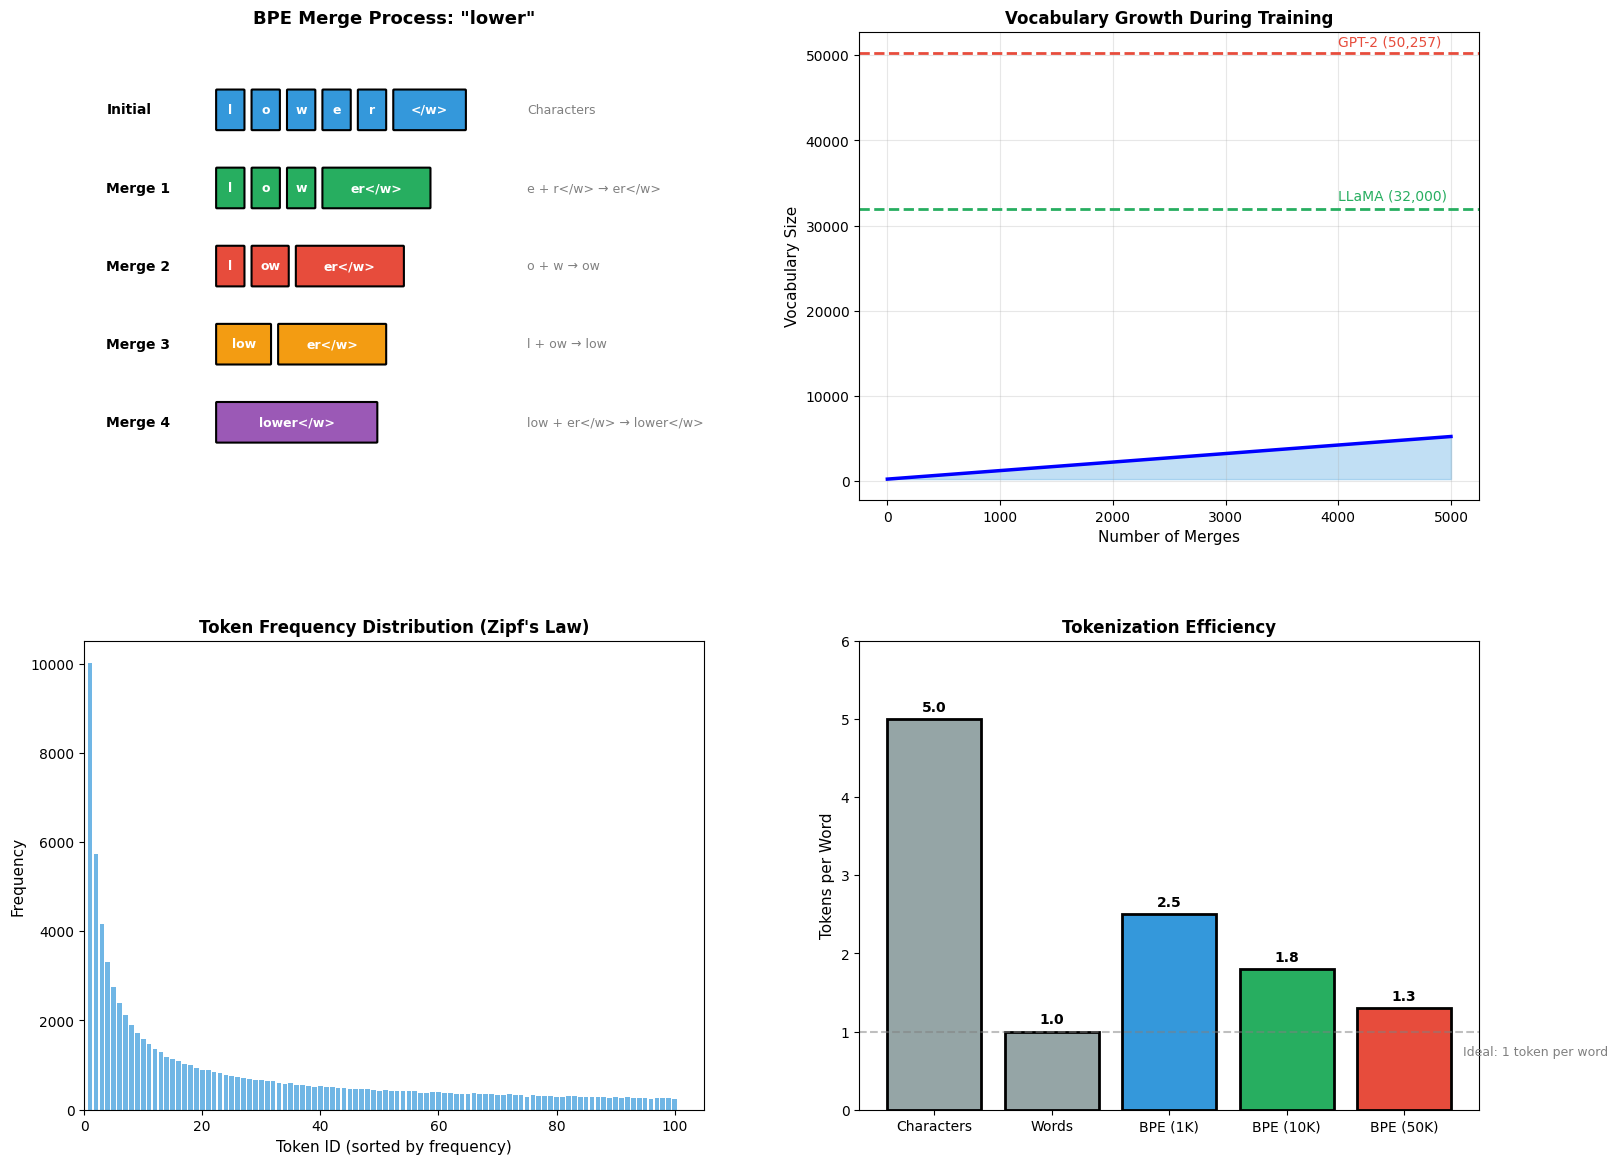

In [7]:
def visualize_bpe_process():
    """
    Visualize the BPE merge process.
    """
    fig = plt.figure(figsize=(18, 14))

    gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)

    # === TOP LEFT: Merge process ===
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 12)
    ax1.axis('off')
    ax1.set_title('BPE Merge Process: "lower"', fontsize=13, fontweight='bold')

    stages = [
        ('Initial', ['l', 'o', 'w', 'e', 'r', '</w>'], 'Characters'),
        ('Merge 1', ['l', 'o', 'w', 'er</w>'], 'e + r</w> → er</w>'),
        ('Merge 2', ['l', 'ow', 'er</w>'], 'o + w → ow'),
        ('Merge 3', ['low', 'er</w>'], 'l + ow → low'),
        ('Merge 4', ['lower</w>'], 'low + er</w> → lower</w>'),
    ]

    colors = ['#3498db', '#27ae60', '#e74c3c', '#f39c12', '#9b59b6']

    for i, (stage, tokens, desc) in enumerate(stages):
        y = 10 - i * 2

        ax1.text(0.5, y, stage, fontsize=10, fontweight='bold', va='center')

        x = 3
        for token in tokens:
            width = max(len(token) * 0.4, 0.6)
            rect = FancyBboxPatch((x, y-0.5), width, 1, boxstyle="round,pad=0.02",
                                  facecolor=colors[i], edgecolor='black', linewidth=1.5)
            ax1.add_patch(rect)
            ax1.text(x + width/2, y, token, ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
            x += width + 0.2

        ax1.text(10, y, desc, fontsize=9, va='center', color='gray')

    # === TOP RIGHT: Vocabulary growth ===
    ax2 = fig.add_subplot(gs[0, 1])

    merges = list(range(0, 5001, 100))
    vocab_sizes = [256 + m for m in merges]  # Start with 256 bytes

    ax2.plot(merges, vocab_sizes, 'b-', linewidth=2.5)
    ax2.fill_between(merges, 256, vocab_sizes, alpha=0.3, color='#3498db')

    ax2.axhline(y=50257, color='#e74c3c', linestyle='--', linewidth=2)
    ax2.text(4000, 51000, 'GPT-2 (50,257)', fontsize=10, color='#e74c3c')

    ax2.axhline(y=32000, color='#27ae60', linestyle='--', linewidth=2)
    ax2.text(4000, 33000, 'LLaMA (32,000)', fontsize=10, color='#27ae60')

    ax2.set_xlabel('Number of Merges', fontsize=11)
    ax2.set_ylabel('Vocabulary Size', fontsize=11)
    ax2.set_title('Vocabulary Growth During Training', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # === BOTTOM LEFT: Token frequency distribution ===
    ax3 = fig.add_subplot(gs[1, 0])

    # Simulated token frequency (Zipf-like)
    np.random.seed(42)
    token_ids = np.arange(1, 1001)
    frequencies = 10000 / (token_ids ** 0.8) + np.random.randn(1000) * 10
    frequencies = np.maximum(frequencies, 1)

    ax3.bar(token_ids[:100], frequencies[:100], color='#3498db', alpha=0.7)
    ax3.set_xlabel('Token ID (sorted by frequency)', fontsize=11)
    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.set_title('Token Frequency Distribution (Zipf\'s Law)', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 105)

    # === BOTTOM RIGHT: Compression ratio ===
    ax4 = fig.add_subplot(gs[1, 1])

    methods = ['Characters', 'Words', 'BPE (1K)', 'BPE (10K)', 'BPE (50K)']
    tokens_per_word = [5.0, 1.0, 2.5, 1.8, 1.3]
    colors = ['#95a5a6', '#95a5a6', '#3498db', '#27ae60', '#e74c3c']

    bars = ax4.bar(methods, tokens_per_word, color=colors, edgecolor='black', linewidth=2)

    ax4.set_ylabel('Tokens per Word', fontsize=11)
    ax4.set_title('Tokenization Efficiency', fontsize=12, fontweight='bold')
    ax4.set_ylim(0, 6)

    for bar, ratio in zip(bars, tokens_per_word):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{ratio}', ha='center', fontsize=10, fontweight='bold')

    ax4.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax4.text(4.5, 0.7, 'Ideal: 1 token per word', fontsize=9, color='gray')

    plt.tight_layout()
    plt.show()

visualize_bpe_process()

---

## 3. Byte-Level BPE: The GPT-2 Innovation

### 3.1 The Problem with Character-Level BPE

Standard BPE operates on characters, but:
- Unicode has 150,000+ characters
- Many rare characters (emoji, Chinese, etc.)
- Need `<UNK>` token for unseen characters

### 3.2 The Solution: Bytes as Base Vocabulary

GPT-2's insight: **Use bytes (0-255) as the base vocabulary.**

- Any text can be encoded as bytes (UTF-8)
- Only 256 base tokens needed
- **No unknown tokens ever!**

In [8]:
class ByteLevelBPETokenizer:
    """
    Byte-Level BPE Tokenizer (GPT-2 style).

    Key innovation: Use bytes (0-255) as base vocabulary.
    This means ANY text can be encoded without unknown tokens.
    """

    def __init__(self, vocab_size: int = 50257):
        self.vocab_size = vocab_size
        self.merges: Dict[Tuple[bytes, bytes], bytes] = {}
        self.vocab: Dict[bytes, int] = {}
        self.inverse_vocab: Dict[int, bytes] = {}

        # GPT-2 uses a clever byte-to-unicode mapping to avoid control characters
        self.byte_encoder = self._bytes_to_unicode()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}

        # Regex pattern for splitting (GPT-2 style)
        # This prevents merging across certain boundaries
        self.pattern = re.compile(
            r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?\d+| ?[^\s\w\d]+|\s+(?!\S)|\s+"""
        )

    @staticmethod
    def _bytes_to_unicode() -> Dict[int, str]:
        """
        Create mapping from bytes to unicode characters.

        GPT-2 maps bytes to printable unicode characters to avoid
        issues with control characters in the vocabulary.
        """
        # Printable ASCII characters
        bs = list(range(ord("!"), ord("~") + 1))
        bs += list(range(ord("¡"), ord("¬") + 1))
        bs += list(range(ord("®"), ord("ÿ") + 1))

        cs = bs[:]
        n = 0
        for b in range(256):
            if b not in bs:
                bs.append(b)
                cs.append(256 + n)
                n += 1

        return {b: chr(c) for b, c in zip(bs, cs)}

    def _get_pairs(self, word: Tuple[str, ...]) -> Set[Tuple[str, str]]:
        """Get all adjacent pairs in a word."""
        pairs = set()
        prev = word[0]
        for char in word[1:]:
            pairs.add((prev, char))
            prev = char
        return pairs

    def train(self, text: str, verbose: bool = False):
        """
        Train the byte-level BPE tokenizer.
        """
        # Convert text to bytes, then to our unicode representation
        words = self.pattern.findall(text)
        word_freqs = Counter()

        for word in words:
            # Convert to bytes, then to unicode representation
            word_bytes = word.encode('utf-8')
            word_unicode = ''.join(self.byte_encoder[b] for b in word_bytes)
            word_freqs[word_unicode] += 1

        # Initialize: each character is a token
        splits = {word: tuple(word) for word in word_freqs}

        # Initial vocabulary: 256 bytes
        vocab = set(self.byte_encoder.values())

        num_merges = self.vocab_size - 256 - 1  # -1 for <|endoftext|>

        if verbose:
            print(f"Training byte-level BPE...")
            print(f"Initial vocab: 256 bytes")
            print(f"Target merges: {num_merges}")
            iterator = tqdm(range(num_merges), desc="Merges")
        else:
            iterator = range(num_merges)

        for _ in iterator:
            # Count all pairs
            pair_counts = Counter()
            for word, freq in word_freqs.items():
                word_split = splits[word]
                for i in range(len(word_split) - 1):
                    pair_counts[(word_split[i], word_split[i+1])] += freq

            if not pair_counts:
                break

            # Best pair
            best_pair = pair_counts.most_common(1)[0][0]
            new_token = best_pair[0] + best_pair[1]

            # Record merge
            self.merges[best_pair] = new_token
            vocab.add(new_token)

            # Apply merge
            new_splits = {}
            for word in splits:
                word_split = list(splits[word])
                new_word_split = []
                i = 0
                while i < len(word_split):
                    if i < len(word_split) - 1 and \
                       (word_split[i], word_split[i+1]) == best_pair:
                        new_word_split.append(new_token)
                        i += 2
                    else:
                        new_word_split.append(word_split[i])
                        i += 1
                new_splits[word] = tuple(new_word_split)
            splits = new_splits

        # Build vocabulary
        self.vocab = {token: i for i, token in enumerate(sorted(vocab))}
        # Add special token
        self.vocab['<|endoftext|>'] = len(self.vocab)
        self.inverse_vocab = {i: t for t, i in self.vocab.items()}

        if verbose:
            print(f"Final vocab size: {len(self.vocab)}")

    def _bpe(self, token: str) -> List[str]:
        """
        Apply BPE to a single token.
        """
        word = tuple(token)

        if len(word) == 1:
            return list(word)

        while True:
            pairs = self._get_pairs(word)

            # Find the pair with highest priority (earliest in merges)
            best_pair = None
            best_rank = float('inf')

            merge_ranks = {pair: i for i, pair in enumerate(self.merges.keys())}

            for pair in pairs:
                if pair in merge_ranks:
                    if merge_ranks[pair] < best_rank:
                        best_rank = merge_ranks[pair]
                        best_pair = pair

            if best_pair is None:
                break

            # Apply the merge
            new_word = []
            i = 0
            while i < len(word):
                if i < len(word) - 1 and (word[i], word[i+1]) == best_pair:
                    new_word.append(self.merges[best_pair])
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            word = tuple(new_word)

        return list(word)

    def encode(self, text: str) -> List[int]:
        """Encode text to token IDs."""
        tokens = []

        for match in self.pattern.finditer(text):
            word = match.group()
            # Convert to bytes, then to our unicode representation
            word_bytes = word.encode('utf-8')
            word_unicode = ''.join(self.byte_encoder[b] for b in word_bytes)

            # Apply BPE
            bpe_tokens = self._bpe(word_unicode)

            for token in bpe_tokens:
                if token in self.vocab:
                    tokens.append(self.vocab[token])

        return tokens

    def decode(self, ids: List[int]) -> str:
        """Decode token IDs to text."""
        tokens = [self.inverse_vocab.get(i, '') for i in ids]
        text_unicode = ''.join(tokens)

        # Convert back from unicode to bytes to text
        text_bytes = bytes([self.byte_decoder[c] for c in text_unicode])
        return text_bytes.decode('utf-8', errors='replace')

    def tokenize(self, text: str) -> List[str]:
        """Tokenize to tokens (not IDs)."""
        tokens = []

        for match in self.pattern.finditer(text):
            word = match.group()
            word_bytes = word.encode('utf-8')
            word_unicode = ''.join(self.byte_encoder[b] for b in word_bytes)
            bpe_tokens = self._bpe(word_unicode)
            tokens.extend(bpe_tokens)

        return tokens


# Test byte-level BPE
print("BYTE-LEVEL BPE TOKENIZER")
print("=" * 60)

# Smaller vocab for demo
byte_bpe = ByteLevelBPETokenizer(vocab_size=500)
byte_bpe.train(training_corpus, verbose=True)

# Test with various texts including non-ASCII
test_texts = [
    "Hello, world!",
    "The cat sat on the mat.",
    "日本語テスト",  # Japanese
    "Émojis: 😀🎉🚀",  # Emoji
    "Ñoño café résumé",  # Accented characters
]

print("\nTesting with various text types:")
print("-" * 60)

for text in test_texts:
    try:
        tokens = byte_bpe.tokenize(text)
        ids = byte_bpe.encode(text)
        decoded = byte_bpe.decode(ids)

        print(f"\nInput: '{text}'")
        print(f"Tokens ({len(tokens)}): {tokens[:10]}{'...' if len(tokens) > 10 else ''}")
        print(f"Decoded: '{decoded}'")
        print(f"Match: {text == decoded}")
    except Exception as e:
        print(f"\nInput: '{text}'")
        print(f"Error: {e}")

BYTE-LEVEL BPE TOKENIZER
Training byte-level BPE...
Initial vocab: 256 bytes
Target merges: 243


Merges:   0%|          | 0/243 [00:00<?, ?it/s]

Final vocab size: 343

Testing with various text types:
------------------------------------------------------------

Input: 'Hello, world!'
Tokens (12): ['H', 'e', 'l', 'l', 'o', ',', 'Ġw', 'o', 'r', 'l']...
Decoded: 'Hello, world!'
Match: True

Input: 'The cat sat on the mat.'
Tokens (7): ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', '.']
Decoded: 'The cat sat on the mat.'
Match: True

Input: '日本語テスト'
Tokens (18): ['æ', 'Ĺ', '¥', 'æ', 'ľ', '¬', 'è', 'ª', 'ŀ', 'ã']...
Decoded: '日本語テスト'
Match: True

Input: 'Émojis: 😀🎉🚀'
Tokens (21): ['Ã', 'ī', 'm', 'o', 'j', 'i', 's', ':', 'Ġ', 'ð']...
Decoded: 'Émojis: 😀🎉🚀'
Match: True

Input: 'Ñoño café résumé'
Tokens (19): ['Ã', 'ĳ', 'o', 'Ã', '±', 'o', 'Ġc', 'a', 'f', 'Ã']...
Decoded: 'Ñoño café résumé'
Match: True


### 3.3 GPT-2's Merge Prevention Rules

GPT-2 adds rules to prevent certain merges:

/tmp/ipython-input-1397413912.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


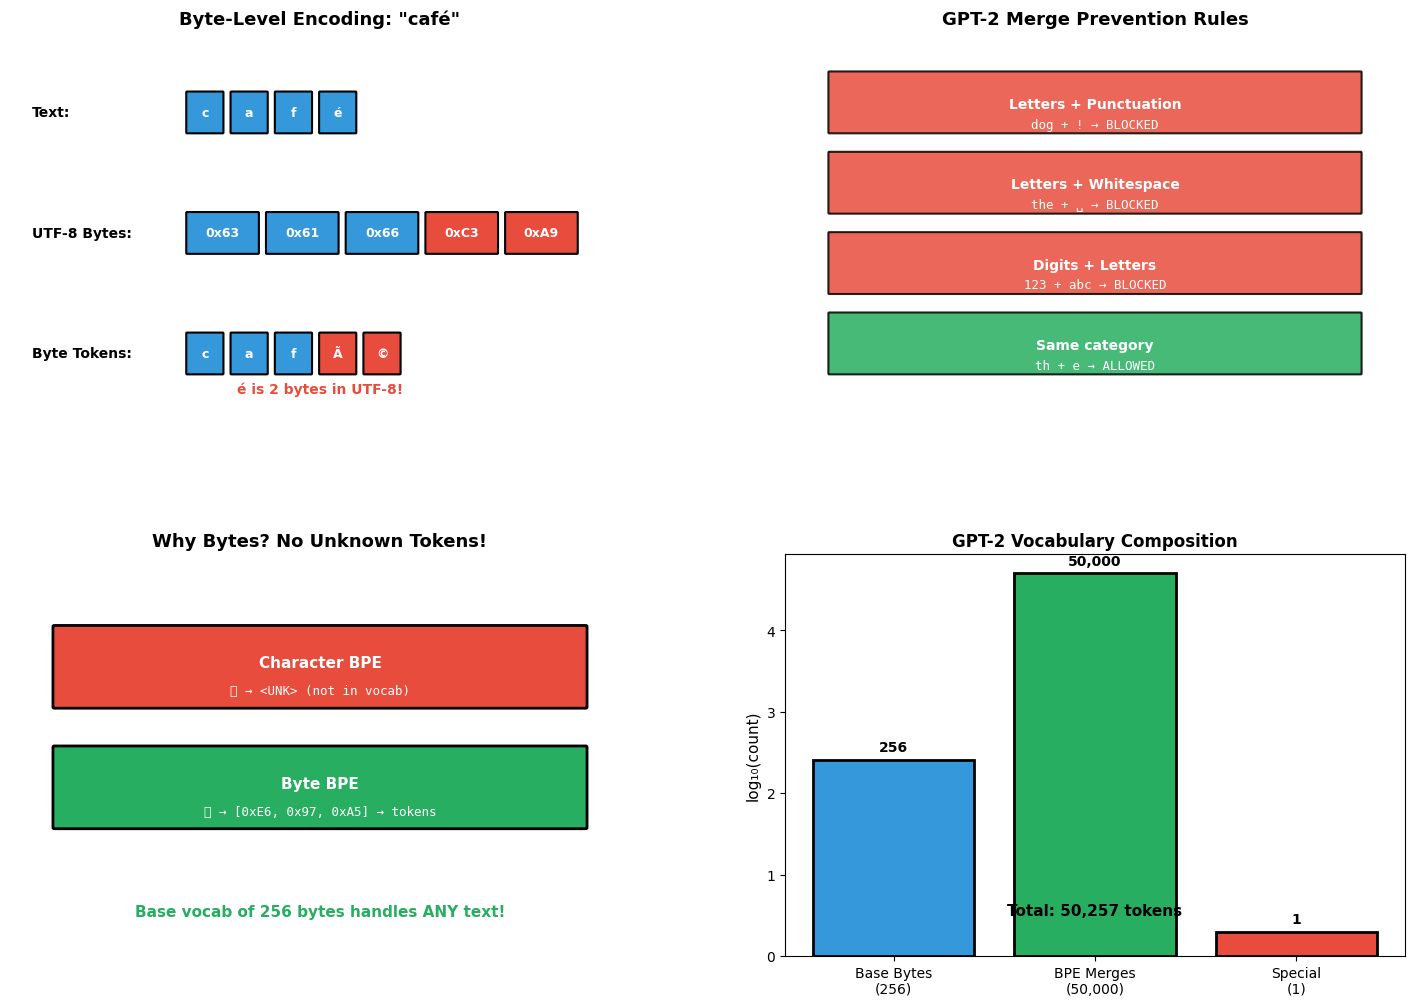

In [9]:
def visualize_byte_level_bpe():
    """
    Visualize byte-level BPE specifics.
    """
    fig = plt.figure(figsize=(18, 12))

    gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)

    # === TOP LEFT: Byte encoding ===
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 10)
    ax1.axis('off')
    ax1.set_title('Byte-Level Encoding: "café"', fontsize=13, fontweight='bold')

    # Show encoding stages
    stages = [
        ('Text', ['c', 'a', 'f', 'é'], ['#3498db'] * 4),
        ('UTF-8 Bytes', ['0x63', '0x61', '0x66', '0xC3', '0xA9'],
         ['#3498db', '#3498db', '#3498db', '#e74c3c', '#e74c3c']),
        ('Byte Tokens', ['c', 'a', 'f', 'Ã', '©'],
         ['#3498db', '#3498db', '#3498db', '#e74c3c', '#e74c3c']),
    ]

    for i, (stage, tokens, colors) in enumerate(stages):
        y = 8 - i * 3
        ax1.text(0.5, y, stage + ':', fontsize=10, fontweight='bold', va='center')

        x = 4
        for token, color in zip(tokens, colors):
            width = max(len(str(token)) * 0.4, 0.8)
            rect = FancyBboxPatch((x, y-0.5), width, 1, boxstyle="round,pad=0.02",
                                  facecolor=color, edgecolor='black', linewidth=1.5)
            ax1.add_patch(rect)
            ax1.text(x + width/2, y, str(token), ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
            x += width + 0.2

    ax1.text(7, 1, 'é is 2 bytes in UTF-8!', fontsize=10, ha='center',
             color='#e74c3c', fontweight='bold')

    # === TOP RIGHT: Character categories ===
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_xlim(0, 14)
    ax2.set_ylim(0, 10)
    ax2.axis('off')
    ax2.set_title('GPT-2 Merge Prevention Rules', fontsize=13, fontweight='bold')

    rules = [
        ('Letters + Punctuation', 'dog + ! → BLOCKED', '#e74c3c'),
        ('Letters + Whitespace', 'the + ␣ → BLOCKED', '#e74c3c'),
        ('Digits + Letters', '123 + abc → BLOCKED', '#e74c3c'),
        ('Same category', 'th + e → ALLOWED', '#27ae60'),
    ]

    for i, (rule, example, color) in enumerate(rules):
        y = 8 - i * 2

        rect = FancyBboxPatch((1, y-0.5), 12, 1.5, boxstyle="round,pad=0.02",
                              facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.85)
        ax2.add_patch(rect)
        ax2.text(7, y+0.2, rule, ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')
        ax2.text(7, y-0.3, example, ha='center', va='center',
                fontsize=9, color='white', family='monospace')

    # === BOTTOM LEFT: Why bytes? ===
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_xlim(0, 14)
    ax3.set_ylim(0, 10)
    ax3.axis('off')
    ax3.set_title('Why Bytes? No Unknown Tokens!', fontsize=13, fontweight='bold')

    comparisons = [
        ('Character BPE', '日 → <UNK> (not in vocab)', '#e74c3c'),
        ('Byte BPE', '日 → [0xE6, 0x97, 0xA5] → tokens', '#27ae60'),
    ]

    for i, (method, result, color) in enumerate(comparisons):
        y = 7 - i * 3

        rect = FancyBboxPatch((1, y-0.8), 12, 2, boxstyle="round,pad=0.03",
                              facecolor=color, edgecolor='black', linewidth=2)
        ax3.add_patch(rect)
        ax3.text(7, y+0.3, method, ha='center', va='center',
                fontsize=11, color='white', fontweight='bold')
        ax3.text(7, y-0.4, result, ha='center', va='center',
                fontsize=9, color='white', family='monospace')

    ax3.text(7, 1, 'Base vocab of 256 bytes handles ANY text!',
             ha='center', fontsize=11, fontweight='bold', color='#27ae60')

    # === BOTTOM RIGHT: GPT-2 vocabulary composition ===
    ax4 = fig.add_subplot(gs[1, 1])

    components = ['Base Bytes\n(256)', 'BPE Merges\n(50,000)', 'Special\n(1)']
    sizes = [256, 50000, 1]
    colors = ['#3498db', '#27ae60', '#e74c3c']

    # Use log scale for visibility
    log_sizes = [np.log10(s + 1) for s in sizes]

    bars = ax4.bar(components, log_sizes, color=colors, edgecolor='black', linewidth=2)

    ax4.set_ylabel('log₁₀(count)', fontsize=11)
    ax4.set_title('GPT-2 Vocabulary Composition', fontsize=12, fontweight='bold')

    for bar, size in zip(bars, sizes):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{size:,}', ha='center', fontsize=10, fontweight='bold')

    ax4.text(1, 0.5, 'Total: 50,257 tokens', ha='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

visualize_byte_level_bpe()

---

## 4. WordPiece: The BERT Approach

### 4.1 How WordPiece Differs from BPE

WordPiece (used by BERT) is similar to BPE but:
- Uses **likelihood** instead of frequency to choose merges
- Uses `##` prefix for continuation tokens

**BPE**: Merge the most **frequent** pair
**WordPiece**: Merge the pair that maximizes **likelihood**

$$\text{score}(a, b) = \frac{\text{freq}(ab)}{\text{freq}(a) \times \text{freq}(b)}$$

In [10]:
class WordPieceTokenizer:
    """
    WordPiece Tokenizer (BERT style).

    Key differences from BPE:
    1. Uses likelihood-based scoring for merges
    2. Uses ## prefix for continuation subwords
    """

    def __init__(self, vocab_size: int = 1000):
        self.vocab_size = vocab_size
        self.vocab: Dict[str, int] = {}
        self.inverse_vocab: Dict[int, str] = {}

        # Special tokens
        self.special_tokens = {
            '[PAD]': 0,
            '[UNK]': 1,
            '[CLS]': 2,
            '[SEP]': 3,
            '[MASK]': 4,
        }

        self.unk_token = '[UNK]'
        self.continuation_prefix = '##'

    def _compute_pair_scores(self, word_freqs: Dict[str, int],
                             splits: Dict[str, List[str]]) -> Dict[Tuple[str, str], float]:
        """
        Compute likelihood-based scores for all pairs.

        score(a,b) = freq(ab) / (freq(a) * freq(b))
        """
        # Count individual token frequencies
        token_freqs = Counter()
        for word, freq in word_freqs.items():
            for token in splits[word]:
                token_freqs[token] += freq

        # Count pair frequencies
        pair_freqs = Counter()
        for word, freq in word_freqs.items():
            symbols = splits[word]
            for i in range(len(symbols) - 1):
                pair_freqs[(symbols[i], symbols[i+1])] += freq

        # Compute scores
        scores = {}
        for pair, freq in pair_freqs.items():
            a, b = pair
            if token_freqs[a] > 0 and token_freqs[b] > 0:
                scores[pair] = freq / (token_freqs[a] * token_freqs[b])

        return scores

    def train(self, text: str, verbose: bool = False):
        """
        Train the WordPiece tokenizer.
        """
        # Preprocessing
        words = re.findall(r"\w+", text.lower())
        word_freqs = Counter(words)

        # Initialize: first char + ##continuation
        splits = {}
        for word in word_freqs:
            if len(word) > 0:
                splits[word] = [word[0]] + [self.continuation_prefix + c for c in word[1:]]

        # Initial vocabulary
        vocab = set()
        for word in splits:
            vocab.update(splits[word])

        if verbose:
            print(f"Initial vocab size: {len(vocab)}")

        num_merges = self.vocab_size - len(vocab) - len(self.special_tokens)

        if verbose:
            iterator = tqdm(range(num_merges), desc="Training WordPiece")
        else:
            iterator = range(num_merges)

        for _ in iterator:
            # Compute scores
            scores = self._compute_pair_scores(word_freqs, splits)

            if not scores:
                break

            # Best pair by score (not frequency!)
            best_pair = max(scores, key=scores.get)

            # Create new token
            a, b = best_pair
            if b.startswith(self.continuation_prefix):
                new_token = a + b[len(self.continuation_prefix):]
            else:
                new_token = a + b

            vocab.add(new_token)

            # Apply merge
            new_splits = {}
            for word in splits:
                symbols = splits[word]
                new_symbols = []
                i = 0
                while i < len(symbols):
                    if i < len(symbols) - 1 and (symbols[i], symbols[i+1]) == best_pair:
                        new_symbols.append(new_token)
                        i += 2
                    else:
                        new_symbols.append(symbols[i])
                        i += 1
                new_splits[word] = new_symbols
            splits = new_splits

        # Build final vocabulary
        self.vocab = dict(self.special_tokens)
        for i, token in enumerate(sorted(vocab), len(self.special_tokens)):
            self.vocab[token] = i

        self.inverse_vocab = {i: t for t, i in self.vocab.items()}

        if verbose:
            print(f"Final vocab size: {len(self.vocab)}")

    def _tokenize_word(self, word: str) -> List[str]:
        """
        Tokenize a single word using greedy longest-match.
        """
        tokens = []
        start = 0

        while start < len(word):
            end = len(word)
            found = False

            while start < end:
                substr = word[start:end]
                if start > 0:
                    substr = self.continuation_prefix + substr

                if substr in self.vocab:
                    tokens.append(substr)
                    found = True
                    break

                end -= 1

            if not found:
                tokens.append(self.unk_token)
                start += 1
            else:
                start = end

        return tokens

    def encode(self, text: str) -> List[int]:
        """Encode text to token IDs."""
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        tokens = []

        for word in words:
            word_tokens = self._tokenize_word(word)
            for token in word_tokens:
                tokens.append(self.vocab.get(token, self.vocab[self.unk_token]))

        return tokens

    def decode(self, ids: List[int]) -> str:
        """Decode token IDs to text."""
        tokens = [self.inverse_vocab.get(i, self.unk_token) for i in ids]

        # Join, handling ## prefix
        text = ''
        for token in tokens:
            if token.startswith(self.continuation_prefix):
                text += token[len(self.continuation_prefix):]
            elif token in self.special_tokens:
                text += ' ' + token + ' '
            else:
                text += ' ' + token

        return text.strip()

    def tokenize(self, text: str) -> List[str]:
        """Tokenize to tokens (not IDs)."""
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        tokens = []
        for word in words:
            tokens.extend(self._tokenize_word(word))
        return tokens


# Train and test WordPiece
print("WORDPIECE TOKENIZER")
print("=" * 60)

wp = WordPieceTokenizer(vocab_size=100)
wp.train(training_corpus, verbose=True)

# Test
test_texts = [
    "The cat sat on the mat.",
    "unhappiness",
    "running",
]

print("\nTesting:")
for text in test_texts:
    tokens = wp.tokenize(text)
    print(f"\n'{text}' → {tokens}")

WORDPIECE TOKENIZER
Initial vocab size: 31


Training WordPiece:   0%|          | 0/64 [00:00<?, ?it/s]

Final vocab size: 100

Testing:

'The cat sat on the mat.' → ['the', 'cat', 'sat', 'on', 'the', 'm', '##a', '##t', '[UNK]']

'unhappiness' → ['[UNK]', '##n', '##h', '##a', '##ppi', '##n', '##e', '##s', '##s']

'running' → ['running']


---

## 5. Unigram: The Probabilistic Alternative

### 5.1 How Unigram Works

Unigram (used by SentencePiece, LLaMA) is fundamentally different:

1. Start with a **large** vocabulary (all substrings)
2. **Remove** tokens that hurt likelihood the least
3. Uses a **language model** to score tokenizations

In [11]:
class UnigramTokenizer:
    """
    Simplified Unigram Tokenizer.

    Unlike BPE (bottom-up), Unigram is top-down:
    1. Start with large vocabulary
    2. Remove tokens that hurt likelihood least
    """

    def __init__(self, vocab_size: int = 1000):
        self.vocab_size = vocab_size
        self.vocab: Dict[str, float] = {}  # token -> log probability
        self.token_to_id: Dict[str, int] = {}
        self.id_to_token: Dict[int, str] = {}

    def _get_substrings(self, word: str, max_len: int = 10) -> List[str]:
        """Get all substrings of a word."""
        substrings = []
        for i in range(len(word)):
            for j in range(i + 1, min(i + max_len + 1, len(word) + 1)):
                substrings.append(word[i:j])
        return substrings

    def _compute_loss(self, word: str) -> float:
        """
        Compute the loss (negative log likelihood) for tokenizing a word.
        Uses Viterbi-like dynamic programming.
        """
        n = len(word)
        # dp[i] = best score to tokenize word[:i]
        dp = [float('inf')] * (n + 1)
        dp[0] = 0

        for i in range(1, n + 1):
            for j in range(max(0, i - 10), i):  # Consider substrings up to length 10
                substr = word[j:i]
                if substr in self.vocab:
                    dp[i] = min(dp[i], dp[j] - self.vocab[substr])

        return dp[n]

    def _tokenize_word_viterbi(self, word: str) -> List[str]:
        """
        Tokenize using Viterbi algorithm to find best segmentation.
        """
        n = len(word)
        dp = [float('inf')] * (n + 1)
        backtrack = [0] * (n + 1)
        dp[0] = 0

        for i in range(1, n + 1):
            for j in range(max(0, i - 10), i):
                substr = word[j:i]
                if substr in self.vocab:
                    score = dp[j] - self.vocab[substr]
                    if score < dp[i]:
                        dp[i] = score
                        backtrack[i] = j

        # Backtrack to get tokens
        tokens = []
        i = n
        while i > 0:
            j = backtrack[i]
            tokens.append(word[j:i])
            i = j

        return tokens[::-1]

    def train(self, text: str, verbose: bool = False):
        """
        Train the Unigram tokenizer.
        """
        # Get words
        words = re.findall(r"\w+", text.lower())
        word_freqs = Counter(words)

        # Initialize with all substrings
        substring_freqs = Counter()
        for word, freq in word_freqs.items():
            for substr in self._get_substrings(word):
                substring_freqs[substr] += freq

        # Keep top candidates (much larger than target vocab)
        initial_vocab_size = self.vocab_size * 10
        top_substrings = substring_freqs.most_common(initial_vocab_size)

        # Initialize vocab with log probabilities
        total = sum(freq for _, freq in top_substrings)
        self.vocab = {substr: np.log(freq / total) for substr, freq in top_substrings}

        # Add single characters (required for fallback)
        for char in set(''.join(words)):
            if char not in self.vocab:
                self.vocab[char] = np.log(1e-10)  # Very low probability

        if verbose:
            print(f"Initial vocab size: {len(self.vocab)}")
            print(f"Target vocab size: {self.vocab_size}")

        # Iteratively remove tokens
        while len(self.vocab) > self.vocab_size:
            # Compute loss for each token's removal
            losses = {}
            for token in list(self.vocab.keys()):
                if len(token) == 1:  # Keep single characters
                    continue

                # Temporarily remove token
                old_prob = self.vocab.pop(token)

                # Compute total loss increase
                loss_increase = 0
                for word, freq in list(word_freqs.items())[:100]:  # Sample for speed
                    if token in word:
                        loss_increase += freq * self._compute_loss(word)

                losses[token] = loss_increase
                self.vocab[token] = old_prob  # Restore

            if not losses:
                break

            # Remove token with smallest loss increase
            worst_token = min(losses, key=losses.get)
            del self.vocab[worst_token]

            if verbose and len(self.vocab) % 100 == 0:
                print(f"Vocab size: {len(self.vocab)}")

        # Build ID mappings
        self.token_to_id = {token: i for i, token in enumerate(sorted(self.vocab.keys()))}
        self.id_to_token = {i: token for token, i in self.token_to_id.items()}

        if verbose:
            print(f"Final vocab size: {len(self.vocab)}")

    def tokenize(self, text: str) -> List[str]:
        """Tokenize text."""
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        tokens = []
        for word in words:
            tokens.extend(self._tokenize_word_viterbi(word))
        return tokens

    def encode(self, text: str) -> List[int]:
        """Encode to IDs."""
        tokens = self.tokenize(text)
        return [self.token_to_id.get(t, 0) for t in tokens]

    def decode(self, ids: List[int]) -> str:
        """Decode from IDs."""
        tokens = [self.id_to_token.get(i, '?') for i in ids]
        return ''.join(tokens)


# Train Unigram (simplified, slow)
print("UNIGRAM TOKENIZER")
print("=" * 60)

unigram = UnigramTokenizer(vocab_size=80)
unigram.train(training_corpus, verbose=True)

# Test
for text in ["The cat sat on the mat.", "running", "happiness"]:
    tokens = unigram.tokenize(text)
    print(f"\n'{text}' → {tokens}")

UNIGRAM TOKENIZER
Initial vocab size: 214
Target vocab size: 80
Vocab size: 200
Vocab size: 100
Final vocab size: 80

'The cat sat on the mat.' → ['the', 'cat', 'sat', 'on', 'the', 'ma', 't', '.']

'running' → ['running']

'happiness' → ['happ', 'in', 'e', 's', 's']


---

## 6. Comparison: Which Tokenizer for Which Model?

| Model | Tokenizer | Vocab Size | Key Feature |
|-------|-----------|------------|-------------|
| GPT-2/3/4 | Byte-level BPE | 50,257 | No UNK tokens |
| BERT | WordPiece | 30,522 | ## continuation |
| RoBERTa | Byte-level BPE | 50,265 | Same as GPT-2 |
| LLaMA | SentencePiece (BPE) | 32,000 | Smaller vocab |
| T5 | SentencePiece (Unigram) | 32,000 | Probabilistic |
| Claude | Custom BPE | ~100K | Optimized |

/tmp/ipython-input-3671040434.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


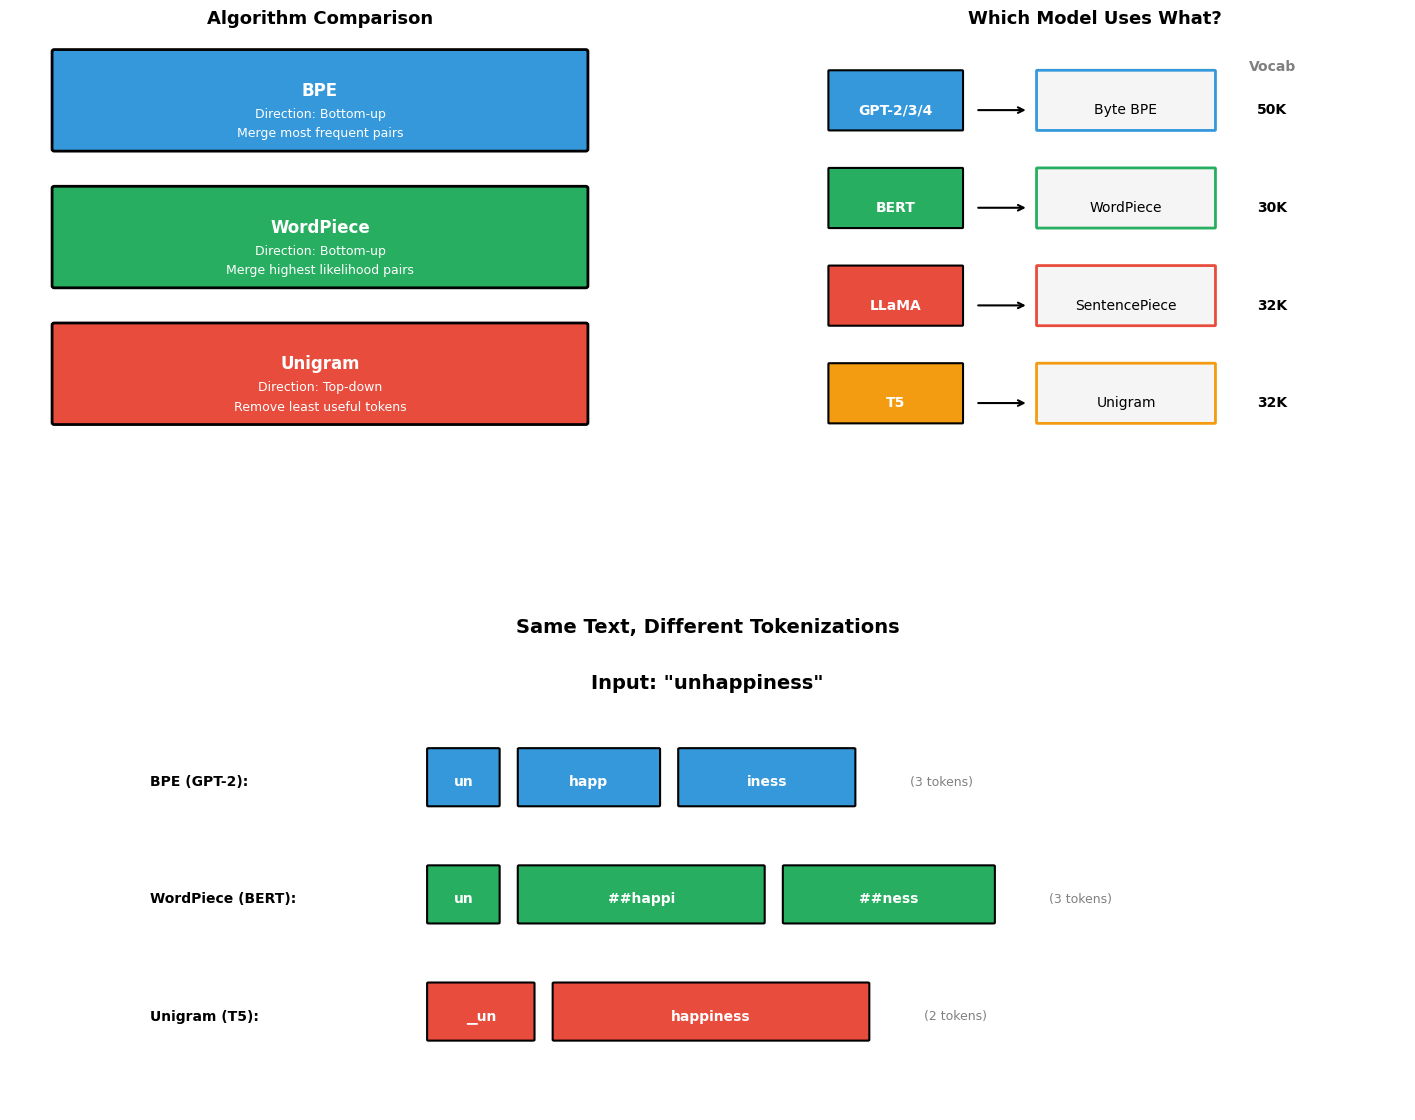

In [12]:
def visualize_tokenizer_comparison():
    """
    Compare different tokenization approaches.
    """
    fig = plt.figure(figsize=(18, 14))

    gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)

    # === TOP LEFT: Algorithm comparison ===
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 12)
    ax1.axis('off')
    ax1.set_title('Algorithm Comparison', fontsize=13, fontweight='bold')

    algos = [
        ('BPE', 'Bottom-up', 'Merge most frequent pairs', '#3498db'),
        ('WordPiece', 'Bottom-up', 'Merge highest likelihood pairs', '#27ae60'),
        ('Unigram', 'Top-down', 'Remove least useful tokens', '#e74c3c'),
    ]

    for i, (name, direction, method, color) in enumerate(algos):
        y = 10 - i * 3.5

        rect = FancyBboxPatch((1, y-1), 12, 2.5, boxstyle="round,pad=0.05",
                              facecolor=color, edgecolor='black', linewidth=2)
        ax1.add_patch(rect)

        ax1.text(7, y+0.5, name, ha='center', va='center',
                fontsize=12, color='white', fontweight='bold')
        ax1.text(7, y-0.1, f'Direction: {direction}', ha='center', va='center',
                fontsize=9, color='white')
        ax1.text(7, y-0.6, method, ha='center', va='center',
                fontsize=9, color='white')

    # === TOP RIGHT: Model usage ===
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_xlim(0, 14)
    ax2.set_ylim(0, 12)
    ax2.axis('off')
    ax2.set_title('Which Model Uses What?', fontsize=13, fontweight='bold')

    models = [
        ('GPT-2/3/4', 'Byte BPE', '50K', '#3498db'),
        ('BERT', 'WordPiece', '30K', '#27ae60'),
        ('LLaMA', 'SentencePiece', '32K', '#e74c3c'),
        ('T5', 'Unigram', '32K', '#f39c12'),
    ]

    for i, (model, tokenizer, vocab, color) in enumerate(models):
        y = 10 - i * 2.5

        # Model name
        rect = FancyBboxPatch((1, y-0.5), 3, 1.5, boxstyle="round,pad=0.02",
                              facecolor=color, edgecolor='black', linewidth=1.5)
        ax2.add_patch(rect)
        ax2.text(2.5, y, model, ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')

        # Arrow
        ax2.annotate('', xy=(5.5, y), xytext=(4.3, y),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

        # Tokenizer
        rect = FancyBboxPatch((5.7, y-0.5), 4, 1.5, boxstyle="round,pad=0.02",
                              facecolor='#f5f5f5', edgecolor=color, linewidth=2)
        ax2.add_patch(rect)
        ax2.text(7.7, y, tokenizer, ha='center', va='center', fontsize=10)

        # Vocab size
        ax2.text(11, y, vocab, ha='center', va='center', fontsize=10, fontweight='bold')

    ax2.text(11, 11, 'Vocab', ha='center', fontsize=10, fontweight='bold', color='gray')

    # === BOTTOM: Example tokenizations ===
    ax3 = fig.add_subplot(gs[1, :])
    ax3.set_xlim(0, 20)
    ax3.set_ylim(0, 10)
    ax3.axis('off')
    ax3.set_title('Same Text, Different Tokenizations', fontsize=14, fontweight='bold')

    text = "unhappiness"
    tokenizations = [
        ('BPE (GPT-2)', ['un', 'happ', 'iness'], '#3498db'),
        ('WordPiece (BERT)', ['un', '##happi', '##ness'], '#27ae60'),
        ('Unigram (T5)', ['▁un', 'happiness'], '#e74c3c'),
    ]

    ax3.text(10, 9, f'Input: "{text}"', ha='center', fontsize=14, fontweight='bold')

    for i, (method, tokens, color) in enumerate(tokenizations):
        y = 7 - i * 2.5

        ax3.text(2, y, method + ':', fontsize=10, fontweight='bold', va='center')

        x = 6
        for token in tokens:
            width = max(len(token) * 0.5, 1)
            rect = FancyBboxPatch((x, y-0.5), width, 1.2, boxstyle="round,pad=0.02",
                                  facecolor=color, edgecolor='black', linewidth=1.5)
            ax3.add_patch(rect)
            ax3.text(x + width/2, y, token, ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')
            x += width + 0.3

        ax3.text(x + 0.5, y, f'({len(tokens)} tokens)', va='center', fontsize=9, color='gray')

    plt.tight_layout()
    plt.show()

visualize_tokenizer_comparison()

---

## 7. Production-Ready Tokenizer

Let's build a complete, production-quality BPE tokenizer with all the features.

In [15]:
@dataclass
class TokenizerConfig:
    """Configuration for the tokenizer."""
    vocab_size: int = 50257
    min_frequency: int = 2
    special_tokens: List[str] = field(default_factory=lambda: [
        '<|endoftext|>', '<|padding|>', '<|unknown|>'
    ])
    max_token_length: int = 100
    lowercase: bool = False


class ProductionBPETokenizer:
    """
    Production-quality BPE Tokenizer.

    Features:
    - Byte-level encoding (no UNK tokens)
    - Special tokens support
    - Save/load functionality
    - Batch encoding/decoding
    - Pre-tokenization with regex
    """

    def __init__(self, config: TokenizerConfig = None):
        self.config = config or TokenizerConfig()

        # Vocabulary
        self.vocab: Dict[str, int] = {}
        self.inverse_vocab: Dict[int, str] = {}
        self.merges: List[Tuple[str, str]] = []  # Ordered list of merges

        # Byte encoding
        self.byte_encoder = self._create_byte_encoder()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}

        # Pre-tokenization pattern (GPT-2 style)
        if self._has_regex_module():
            import regex
            self.pattern = regex.compile(
                r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""",
                regex.UNICODE
            )
        else:
            self.pattern = re.compile(
                r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?\d+| ?[^\s\w\d]+|\s+(?!\S)|\s+"""
            )

        # Cache for encoding
        self._cache: Dict[str, List[str]] = {}

    @staticmethod
    def _has_regex_module() -> bool:
        """Check if regex module is available."""
        try:
            import regex
            return True
        except ImportError:
            return False

    @staticmethod
    def _create_byte_encoder() -> Dict[int, str]:
        """Create byte to unicode mapping."""
        bs = list(range(ord("!"), ord("~") + 1))
        bs += list(range(ord("¡"), ord("¬") + 1))
        bs += list(range(ord("®"), ord("ÿ") + 1))

        cs = bs[:]
        n = 0
        for b in range(256):
            if b not in bs:
                bs.append(b)
                cs.append(256 + n)
                n += 1

        return {b: chr(c) for b, c in zip(bs, cs)}

    def _bytes_to_unicode(self, text: str) -> str:
        """Convert text to unicode representation of bytes."""
        return ''.join(self.byte_encoder[b] for b in text.encode('utf-8'))

    def _unicode_to_bytes(self, text: str) -> str:
        """Convert unicode representation back to text."""
        return bytes([self.byte_decoder[c] for c in text]).decode('utf-8', errors='replace')

    def train(self, texts: List[str], verbose: bool = True):
        """
        Train the tokenizer on a list of texts.
        """
        if verbose:
            print("Training BPE tokenizer...")

        # Count word frequencies
        word_freqs = Counter()
        for text in tqdm(texts, desc="Counting words", disable=not verbose):
            if self.config.lowercase:
                text = text.lower()
            for match in self.pattern.finditer(text):
                word = self._bytes_to_unicode(match.group())
                word_freqs[word] += 1

        # Filter by minimum frequency
        word_freqs = {w: f for w, f in word_freqs.items()
                      if f >= self.config.min_frequency}

        if verbose:
            print(f"Unique words: {len(word_freqs)}")

        # Initialize vocabulary with bytes
        vocab = set(self.byte_encoder.values())

        # Initialize splits
        splits = {word: list(word) for word in word_freqs}

        # Number of merges
        num_merges = self.config.vocab_size - len(vocab) - len(self.config.special_tokens)

        if verbose:
            print(f"Performing {num_merges} merges...")

        for _ in tqdm(range(num_merges), desc="Merges", disable=not verbose):
            # Count pairs
            pair_counts = Counter()
            for word, freq in word_freqs.items():
                symbols = splits[word]
                for i in range(len(symbols) - 1):
                    pair_counts[(symbols[i], symbols[i+1])] += freq

            if not pair_counts:
                break

            # Best pair
            best_pair = pair_counts.most_common(1)[0][0]
            new_token = best_pair[0] + best_pair[1]

            if len(new_token) > self.config.max_token_length:
                continue

            # Record merge
            self.merges.append(best_pair)
            vocab.add(new_token)

            # Apply merge
            new_splits = {}
            for word in splits:
                symbols = splits[word]
                new_symbols = []
                i = 0
                while i < len(symbols):
                    if i < len(symbols) - 1 and (symbols[i], symbols[i+1]) == best_pair:
                        new_symbols.append(new_token)
                        i += 2
                    else:
                        new_symbols.append(symbols[i])
                        i += 1
                new_splits[word] = new_symbols
            splits = new_splits

        # Build final vocabulary
        self.vocab = {}

        # Add special tokens first
        for i, token in enumerate(self.config.special_tokens):
            self.vocab[token] = i

        # Add regular tokens
        for i, token in enumerate(sorted(vocab), len(self.config.special_tokens)):
            self.vocab[token] = i

        self.inverse_vocab = {i: t for t, i in self.vocab.items()}

        if verbose:
            print(f"Final vocabulary size: {len(self.vocab)}")

    def _bpe(self, token: str) -> List[str]:
        """Apply BPE to a token."""
        if token in self._cache:
            return self._cache[token]

        word = list(token)

        for pair in self.merges:
            new_word = []
            i = 0
            while i < len(word):
                if i < len(word) - 1 and (word[i], word[i+1]) == pair:
                    new_word.append(pair[0] + pair[1])
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            word = new_word

        self._cache[token] = word
        return word

    def encode(self, text: str, add_special_tokens: bool = False) -> List[int]:
        """Encode text to token IDs."""
        if self.config.lowercase:
            text = text.lower()

        ids = []

        if add_special_tokens and '<|endoftext|>' in self.vocab:
            ids.append(self.vocab['<|endoftext|>'])

        for match in self.pattern.finditer(text):
            word = self._bytes_to_unicode(match.group())
            tokens = self._bpe(word)

            for token in tokens:
                if token in self.vocab:
                    ids.append(self.vocab[token])
                elif '<|unknown|>' in self.vocab:
                    ids.append(self.vocab['<|unknown|>'])

        return ids

    def decode(self, ids: List[int], skip_special_tokens: bool = True) -> str:
        """Decode token IDs to text."""
        tokens = []
        for i in ids:
            token = self.inverse_vocab.get(i, '')
            if skip_special_tokens and token in self.config.special_tokens:
                continue
            tokens.append(token)

        text_unicode = ''.join(tokens)
        return self._unicode_to_bytes(text_unicode)

    def tokenize(self, text: str) -> List[str]:
        """Tokenize text to tokens."""
        if self.config.lowercase:
            text = text.lower()

        tokens = []
        for match in self.pattern.finditer(text):
            word = self._bytes_to_unicode(match.group())
            tokens.extend(self._bpe(word))

        return tokens

    def batch_encode(self, texts: List[str],
                     padding: bool = True,
                     max_length: int = None) -> Dict[str, List[List[int]]]:
        """Batch encode multiple texts."""
        all_ids = [self.encode(text) for text in texts]

        if max_length:
            all_ids = [ids[:max_length] for ids in all_ids]

        if padding:
            max_len = max(len(ids) for ids in all_ids)
            pad_id = self.vocab.get('<|padding|>', 0)

            attention_mask = []
            for i, ids in enumerate(all_ids):
                mask = [1] * len(ids) + [0] * (max_len - len(ids))
                attention_mask.append(mask)
                all_ids[i] = ids + [pad_id] * (max_len - len(ids))

            return {
                'input_ids': all_ids,
                'attention_mask': attention_mask
            }

        return {'input_ids': all_ids}

    def save(self, path: str):
        """Save tokenizer to file."""
        data = {
            'config': {
                'vocab_size': self.config.vocab_size,
                'min_frequency': self.config.min_frequency,
                'special_tokens': self.config.special_tokens,
                'max_token_length': self.config.max_token_length,
                'lowercase': self.config.lowercase,
            },
            'vocab': self.vocab,
            'merges': self.merges,
        }

        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

    @classmethod
    def load(cls, path: str) -> 'ProductionBPETokenizer':
        """Load tokenizer from file."""
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        config = TokenizerConfig(**data['config'])
        tokenizer = cls(config)
        tokenizer.vocab = data['vocab']
        tokenizer.inverse_vocab = {int(i): t for t, i in tokenizer.vocab.items()}
        tokenizer.merges = [tuple(m) for m in data['merges']]

        return tokenizer


# Train and test the production tokenizer
print("PRODUCTION BPE TOKENIZER")
print("=" * 70)

config = TokenizerConfig(vocab_size=500)
prod_tokenizer = ProductionBPETokenizer(config)

# Training texts
training_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Machine learning is transforming the world of technology.",
    "Natural language processing enables computers to understand human language.",
    "Deep learning models can recognize patterns in complex data.",
    "Transformers have revolutionized the field of NLP.",
] * 10

prod_tokenizer.train(training_texts, verbose=True)

# Test
test_text = "Machine learning is amazing!"
print(f"\nTest: '{test_text}'")
print(f"Tokens: {prod_tokenizer.tokenize(test_text)}")
print(f"IDs: {prod_tokenizer.encode(test_text)}")
print(f"Decoded: '{prod_tokenizer.decode(prod_tokenizer.encode(test_text))}'")

# Batch encoding
batch = ["Hello world", "Machine learning", "AI"]
batch_encoded = prod_tokenizer.batch_encode(batch)
print(f"\nBatch encoding:")
for text, ids, mask in zip(batch, batch_encoded['input_ids'], batch_encoded['attention_mask']):
    print(f"  '{text}' → IDs: {ids}, Mask: {mask}")

PRODUCTION BPE TOKENIZER
Training BPE tokenizer...


Counting words:   0%|          | 0/50 [00:00<?, ?it/s]

Unique words: 38
Performing 241 merges...


Merges:   0%|          | 0/241 [00:00<?, ?it/s]

Final vocabulary size: 419

Test: 'Machine learning is amazing!'
Tokens: ['Machine', 'Ġlearning', 'Ġis', 'Ġ', 'a', 'm', 'a', 'z', 'ing', '!']
IDs: [54, 323, 304, 262, 82, 105, 82, 131, 100, 3]
Decoded: 'Machine learning is amazing!'

Batch encoding:
  'Hello world' → IDs: [45, 89, 103, 103, 111, 383], Mask: [1, 1, 1, 1, 1, 1]
  'Machine learning' → IDs: [54, 323, 1, 1, 1, 1], Mask: [1, 1, 0, 0, 0, 0]
  'AI' → IDs: [35, 46, 1, 1, 1, 1], Mask: [1, 1, 0, 0, 0, 0]


---

## Summary

### What We Built

| Tokenizer | Key Feature | Use Case |
|-----------|-------------|----------|
| **CharacterTokenizer** | Simple baseline | Understanding only |
| **WordTokenizer** | Word-level | Legacy systems |
| **BPETokenizer** | Subword, frequency-based | General purpose |
| **ByteLevelBPE** | No UNK tokens | GPT-2 style |
| **WordPieceTokenizer** | Likelihood-based | BERT style |
| **UnigramTokenizer** | Probabilistic | SentencePiece |
| **ProductionBPETokenizer** | Full-featured | Production use |

### Key Insights

1. **Subword tokenization** is essential for modern NLP
2. **Byte-level** encoding eliminates unknown tokens
3. **BPE** is simple and effective (frequency-based)
4. **WordPiece** uses likelihood (slightly different results)
5. **Unigram** is probabilistic (top-down approach)

## References

1. Sennrich et al. (2016). [Neural Machine Translation of Rare Words with Subword Units](https://arxiv.org/abs/1508.07909) - Original BPE
2. Radford et al. (2019). [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) - Byte-level BPE
3. Devlin et al. (2019). [BERT](https://arxiv.org/abs/1810.04805) - WordPiece
4. Kudo (2018). [Subword Regularization](https://arxiv.org/abs/1804.10959) - Unigram/SentencePiece